# Applying ML Methods

This notebook applies machine learning to the dataset prepared in the EDA stage
(`ipo_final.csv`, 247 IPOs from 2013–2025). The goal is to predict whether
an IPO preserved real (USD) value over a given horizon.

**Task:** binary classification.
- `target_12m_cls` = 1 if 12-month USD return > 0, else 0
- `target_24m_cls` = 1 if 24-month USD return > 0, else 0

**Two feature variants:**
- **pre-IPO** — only features known at offering time
- **early-signal** — adds `tavan_days` (consecutive +10% days after listing),
  which we tested in EDA hypothesis 8

**Models:** a Dummy baseline, Lasso (L1 logistic regression), and LightGBM
with a small grid search.

**Methodology:**
- Time-ordered 70/15/15 split (we sort by listing date because random splits
  don't make sense for IPO data over time)
- `RobustScaler` on numerics, `log1p` on heavy-tailed features (price,
  market cap, free float value)
- One-hot for the grouped sector column, smoothed target encoding for
  underwriter (handles consortium IPOs)
- All preprocessing fit on train only
- TimeSeriesSplit cross-validation for picking hyperparameters
- We report Average Precision (AP) and F1, not accuracy, because the classes
  aren't perfectly balanced
- Final model retrained on train+val combined, then evaluated once on test


## 1. Setup & imports

In [12]:
!pip install lightgbm --quiet

In [13]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegressionCV
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    average_precision_score, f1_score, precision_recall_curve,
    confusion_matrix,
)

import lightgbm as lgb
from lightgbm import LGBMClassifier

RNG = 42
np.random.seed(RNG)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

## 2. Load data and parse dates

In [14]:
df = pd.read_csv("ipo_final.csv")
df["date"] = pd.to_datetime(df["Borsada İşlem Görme Tarihi"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Total IPOs: {len(df)}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

Total IPOs: 247
Date range: 2013-02-22 → 2025-12-18


## 3. Define classification targets

We make two binary targets: did the IPO have a positive USD return at 12 months,
and at 24 months. We use USD-adjusted returns rather than TRY because Turkish
inflation has been high, so a TRY-positive return often doesn't mean the IPO
actually preserved value in real terms.

The helper below preserves NaN for IPOs that are too recent to have reached the
horizon (e.g. an IPO from late 2024 hasn't had 24 months yet). Without this,
those rows would silently get labeled as "negative outcome".


In [15]:
def _binarize_preserve_nan(s):
    out = pd.Series(pd.NA, index=s.index, dtype="Int64")
    obs = s.notna()
    out.loc[obs] = (s[obs] > 0).astype(int)
    return out

df["target_12m_cls"] = _binarize_preserve_nan(df["return_12m_usd"])
df["target_24m_cls"] = _binarize_preserve_nan(df["return_24m_usd"])

print("Class balance:")
for h in ["12m", "24m"]:
    cls = df[f"target_{h}_cls"].dropna().astype(int)
    n, pos = len(cls), int(cls.sum())
    print(f"  {h}: n={n}, positive={pos} ({pos/n:.1%})")

Class balance:
  12m: n=239, positive=136 (56.9%)
  24m: n=202, positive=120 (59.4%)


## 4. Feature engineering

A few cleaning and derivation steps:

1. **Clean up underwriter names.** The raw column has 87 unique entries but many
   are the same firm written differently — legal-suffix variants ("Menkul Değerler"
   vs "Menkul Kıymetler"), capitalization differences, typos, or rebrands like
   QNB Finans → QNB. Some IPOs are also done by consortia of multiple firms,
   so we parse those into lists. We split on "A.Ş." boundaries because every
   Turkish corporate name ends with that suffix, which lets us correctly handle
   names that contain "ve" inside them (like "Türkiye Kalkınma ve Yatırım Bankası"
   which is one firm, not two). After cleanup the 87 entries reduce to 35
   canonical firms.

2. **Group rare sectors** into "Other". We keep the top 10 sectors and merge the
   rest because most of them have only 1–2 IPOs, so one-hot encoding all 39
   sectors would create lots of sparse columns we don't really have data for.

3. **Compute USD offering price** = TRY price ÷ exchange rate at listing date.
   Same reason as USD returns — the TRY value isn't comparable across years.

4. **Compute free-float value in USD** = ratio × market cap. This was significant
   in EDA hypothesis 7, so we want it as a feature.

5. **Pick the feature list.** We exclude `listing_year` (the test years aren't
   in the training range, so the model can't learn from year as a numeric
   feature), `usdtry_at_listing` (it just goes up over time, same problem), and
   the boolean `BIST100_above_SMA200` (the continuous `BIST100_SMA200_pct`
   already contains both above/below info and the magnitude).


In [16]:
import re

ALIASES = {
    "AK Yatırım": "Ak Yatırım",
    "Yapı Kredi": "Yapı Kredi Yatırım",
    "TSKB": "Türkiye Sınai Kalkınma Bankası",
    "Türkiye Kalkınma Yatırım Bankası": "Türkiye Kalkınma ve Yatırım Bankası",
    "Global": "Global Yatırım",
    "Finans Yatırım": "QNB Yatırım",
    "QNB Finans Yatırım": "QNB Yatırım",
    "A1 Capital Yatırım": "A1 Capital",
    "Vakıf menkul": "Vakıf Yatırım",
    "Vakıf": "Vakıf Yatırım",
    "Ünlü": "Ünlü Yatırım",
}


def canonicalize_firm(name):
    s = name.strip(' ,;-_."\'')
    if not s:
        return ""
    s = re.sub(r"\([^)]*\)", "", s)
    for suf in [r"A\.[Şş]\.", r"A\.[Şş]", r"Menkul Değerler", r"Menkul Kıymetler", r"Menkul"]:
        s = re.sub(suf, "", s, flags=re.IGNORECASE)
    s = re.sub(r"\s+", " ", s).strip(" ,.-_")
    s = s.replace("Yatrırım", "Yatırım").replace("Ahlatcı", "Ahlatçı").replace("Değerer", "")
    s = re.sub(r"\s+", " ", s).strip(" ,.-_")
    return ALIASES.get(s, s)


def parse_underwriters(raw):
    if pd.isna(raw):
        return []
    s = str(raw).strip().strip('"')
    # "X liderliğinde konsorsiyum" → take only X
    lider_pat = (r"^(.+?)\s*[Ll]iderliğinde(?:ki)?"
                 r"(?:\s+\d+\s+aracı\s+kurum\s+ile\s+birlikte)?"
                 r"\s+[Kk]onsorsiyum\s*$")
    m = re.match(lider_pat, s)
    if m:
        firm = canonicalize_firm(m.group(1))
        return [firm] if firm else []
    s = re.sub(r"\([^)]*\)", "", s)
    parts = re.split(r"(?<=A\.[Şş]\.)\s*", s)
    if len(parts) <= 1:
        parts = re.split(r"\s*,\s*|\s+-\s+|\s+ve\s+", s)
    out, seen = [], set()
    for p in parts:
        p = p.strip(' ,;-_"')
        p = re.sub(r"^ve\s+", "", p, flags=re.IGNORECASE)
        if not p:
            continue
        canon = canonicalize_firm(p)
        if canon and canon not in seen:
            out.append(canon)
            seen.add(canon)
    return out


df = df.rename(columns={
    "Halka Arz Oranı (%)": "free_float_ratio",
    "Halka Arz Fiyatı (TL)": "offering_price_try",
})
df["uw_list"] = df["Halka Arza Aracılık Eden Kurum"].apply(parse_underwriters)

n_canon = pd.Series([f for lst in df["uw_list"] for f in lst]).nunique()
print(f"Underwriter cleanup: 87 raw entries → {n_canon} canonical firms")
print(f"Firm-count distribution per IPO:")
print(df["uw_list"].apply(len).value_counts().sort_index().to_string())

# Group rare sectors
top_sectors = df["Sektör"].value_counts().head(10).index.tolist()
df["sector_grouped"] = df["Sektör"].where(df["Sektör"].isin(top_sectors), "Other")

# Derive USD offering price and free-float value
df["offering_price_usd"] = df["offering_price_try"] / df["usdtry_at_listing"]
df["free_float_value_usd"] = df["free_float_ratio"] / 100.0 * df["market_cap_usd"]

# Feature lists
NUM_FEATURES_PRE = [
    "free_float_ratio", "offering_price_usd", "market_cap_usd",
    "free_float_value_usd", "BIST100_SMA200_pct",
]
CAT_FEATURES_PRE = ["sector_grouped"]
UNDERWRITER_LIST_COL = "uw_list"
EARLY_NUM_EXTRAS = ["tavan_days"]

print()
print(f"Pre-IPO numeric features ({len(NUM_FEATURES_PRE)}): {NUM_FEATURES_PRE}")
print(f"Pre-IPO categorical: {CAT_FEATURES_PRE}")
print(f"Sectors after grouping: {df['sector_grouped'].nunique()}")

Underwriter cleanup: 87 raw entries → 35 canonical firms
Firm-count distribution per IPO:
uw_list
1    211
2     27
3      7
4      2

Pre-IPO numeric features (5): ['free_float_ratio', 'offering_price_usd', 'market_cap_usd', 'free_float_value_usd', 'BIST100_SMA200_pct']
Pre-IPO categorical: ['sector_grouped']
Sectors after grouping: 11


## 5. Time-ordered train/val/test split

We split 70/15/15 by listing date — the oldest 70% of IPOs go into training,
the next 15% into validation, and the most recent 15% into test. We don't use
random splits because IPOs from the same time period share macro context (rate
environment, market sentiment), so a random split could let the model see
"future" information at training time.

The test set ends up being the most recent IPOs, so reporting test performance
is closer to "how well would this model predict new IPOs going forward".


In [17]:
def time_ordered_split(df, target_col, train_frac=0.70, val_frac=0.15):
    sub = df.dropna(subset=[target_col]).sort_values("date").reset_index(drop=True)
    n = len(sub)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    train = sub.iloc[:n_train].copy()
    val = sub.iloc[n_train:n_train + n_val].copy()
    test = sub.iloc[n_train + n_val:].copy()
    return train, val, test

for target in ["target_12m_cls", "target_24m_cls"]:
    tr, va, te = time_ordered_split(df, target)
    print(f"\nTarget = {target}")
    print(f"  Train: n={len(tr):3d}  dates {tr['date'].min().date()} → {tr['date'].max().date()}  "
          f"pos={int(tr[target].sum())}/{len(tr)} ({tr[target].mean():.1%})")
    print(f"  Val:   n={len(va):3d}  dates {va['date'].min().date()} → {va['date'].max().date()}  "
          f"pos={int(va[target].sum())}/{len(va)} ({va[target].mean():.1%})")
    print(f"  Test:  n={len(te):3d}  dates {te['date'].min().date()} → {te['date'].max().date()}  "
          f"pos={int(te[target].sum())}/{len(te)} ({te[target].mean():.1%})")


Target = target_12m_cls
  Train: n=167  dates 2013-02-22 → 2023-08-21  pos=96/167 (57.5%)
  Val:   n= 35  dates 2023-08-23 → 2024-04-04  pos=21/35 (60.0%)
  Test:  n= 37  dates 2024-04-26 → 2025-02-21  pos=19/37 (51.4%)

Target = target_24m_cls
  Train: n=141  dates 2013-02-22 → 2023-01-12  pos=88/141 (62.4%)
  Val:   n= 30  dates 2023-01-18 → 2023-09-12  pos=14/30 (46.7%)
  Test:  n= 31  dates 2023-09-14 → 2024-04-04  pos=18/31 (58.1%)


## 6. Preprocessing helpers

Three helpers used by the main runner:

1. **Target encoder for underwriter** (multi-firm aware). For each canonical firm,
   we compute the average target across the firm's training IPOs, smoothed
   toward the global mean (so a firm with only 1 IPO doesn't get a wild value).
   For consortium IPOs that have multiple firms, we average the firms' encoded
   values. Everything is fit on training data only.

2. **Preprocessor**, built as a `ColumnTransformer`. It imputes missing values
   (median for numerics, most frequent for categoricals), log-transforms
   heavy-tailed features (price, market cap, free float value), robust-scales
   the numerics, and one-hot encodes the grouped sector. Fitting it on training
   data and then transforming val/test guarantees we don't leak any val/test
   information into the preprocessing step.

3. **Feature-name reconstructor** so that after preprocessing we still know
   which output column came from which input column — useful for printing
   Lasso coefficients and looking at importances.


In [18]:
def fit_target_encoder_multi(train_df, list_col, target_col, smoothing=10):
    """Smoothed target encoding for a column of LISTS (multi-firm aware).
    Returns (mapping_dict, global_mean)."""
    tmp = train_df[[list_col, target_col]].copy()
    tmp[target_col] = tmp[target_col].astype(float)
    global_mean = tmp[target_col].mean()
    exploded = tmp.explode(list_col).dropna(subset=[list_col])
    counts = exploded[list_col].value_counts()
    means = exploded.groupby(list_col)[target_col].mean()
    smoothed = (counts * means + smoothing * global_mean) / (counts + smoothing)
    return smoothed.to_dict(), global_mean


def apply_target_encoder_multi(df, list_col, mapping, fallback):
    """For each row's list of firms, look up each in mapping and average."""
    def encode_row(firms):
        if not isinstance(firms, list) or len(firms) == 0:
            return fallback
        vals = [mapping.get(f, fallback) for f in firms]
        return float(np.mean(vals))
    return df[list_col].apply(encode_row).astype(float)


def make_preprocessor(numeric_features, sector_feature):
    """ColumnTransformer: log+scale heavy-tailed nums, scale plain nums,
    one-hot the sector column."""
    LOG_FEATURES = ["offering_price_usd", "market_cap_usd", "free_float_value_usd"]
    log_features = [c for c in LOG_FEATURES if c in numeric_features]
    plain_numeric = [c for c in numeric_features if c not in log_features]

    num_log = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("log",    FunctionTransformer(np.log1p, validate=False)),
        ("scale",  RobustScaler()),
    ])
    num_plain = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  RobustScaler()),
    ])
    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer([
        ("num_log",    num_log,    log_features),
        ("num_plain",  num_plain,  plain_numeric),
        ("cat_sector", cat_pipe,   [sector_feature]),
    ], remainder="drop")


def get_feature_names(preprocessor, numeric_features, sector_feature):
    LOG_FEATURES = ["offering_price_usd", "market_cap_usd", "free_float_value_usd"]
    log_features = [c for c in LOG_FEATURES if c in numeric_features]
    plain_numeric = [c for c in numeric_features if c not in log_features]
    names = [f"log_{c}" for c in log_features] + plain_numeric
    onehot = preprocessor.named_transformers_["cat_sector"].named_steps["onehot"]
    names += [f"sector__{c}" for c in onehot.get_feature_names_out([sector_feature])]
    return names

## 7. Classification runner — Lasso (L1) and LightGBM

This function takes a (target, feature set) combination and runs the full
pipeline:

- **Dummy** — predicts the train class prior as a constant probability for every
  test row. We include it as a no-skill baseline so we can see how much real
  improvement the actual models give.
- **Lasso** (L1 logistic regression) using `LogisticRegressionCV`. It searches
  25 values of the regularization strength `C` over a log-spaced grid using
  5-fold time-series cross-validation, picks the best `C` by Average Precision,
  and refits. Because of the L1 penalty, some feature coefficients get pushed
  to exactly 0 — so feature selection happens during training, not as a
  separate step.
- **LightGBM** with a small grid search. We try 27 combinations of learning
  rate, num_leaves, and max_depth. For each, we use early stopping on the
  validation set to pick the number of trees automatically. The combination
  with the best validation AP wins.

The function returns a dictionary of results (predictions, AP, F1, fitted
parameters) for each model.


In [19]:
def run_classification(df, target_col, num_features, sector_feature,
                       underwriter_list_col, label):
    # 1. Time-ordered split
    train, val, test = time_ordered_split(df, target_col)

    # 2. Underwriter target encoding — multi-firm-aware, train-only fit
    uw_map, uw_global = fit_target_encoder_multi(train, underwriter_list_col, target_col, smoothing=10)
    train["uw_te"] = apply_target_encoder_multi(train, underwriter_list_col, uw_map, uw_global)
    val["uw_te"]   = apply_target_encoder_multi(val,   underwriter_list_col, uw_map, uw_global)
    test["uw_te"]  = apply_target_encoder_multi(test,  underwriter_list_col, uw_map, uw_global)

    num_features_full = num_features + ["uw_te"]

    # 3. Preprocess (fit on train only)
    pre = make_preprocessor(num_features_full, sector_feature)
    feat_cols = num_features_full + [sector_feature]

    X_train = pre.fit_transform(train[feat_cols])
    X_val   = pre.transform(val[feat_cols])
    X_test  = pre.transform(test[feat_cols])
    y_train = train[target_col].astype(int).values
    y_val   = val[target_col].astype(int).values
    y_test  = test[target_col].astype(int).values

    feature_names = get_feature_names(pre, num_features_full, sector_feature)

    results = {"label": label, "feature_names": feature_names,
               "y_test": y_test, "models": {}}

    # 4. Dummy baseline
    dummy = DummyClassifier(strategy="prior")
    dummy.fit(X_train, y_train)
    p = dummy.predict_proba(X_test)[:, 1]
    results["models"]["Dummy"] = {
        "proba_test": p,
        "ap": average_precision_score(y_test, p),
        "f1": f1_score(y_test, (p >= 0.5).astype(int)),
    }

    # 5. Lasso (L1 logistic), CV-tuned C
    lasso_clf = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 25), penalty="l1", solver="saga",
        cv=TimeSeriesSplit(n_splits=5), scoring="average_precision",
        max_iter=5000, random_state=RNG, class_weight="balanced",
    )
    lasso_clf.fit(X_train, y_train)
    p = lasso_clf.predict_proba(X_test)[:, 1]
    results["models"]["Lasso"] = {
        "proba_test": p,
        "ap": average_precision_score(y_test, p),
        "f1": f1_score(y_test, (p >= 0.5).astype(int)),
        "C": lasso_clf.C_[0],
        "coefs": pd.Series(lasso_clf.coef_[0], index=feature_names),
    }

    # 6. LightGBM grid search
    LGBM_GRID = {
        "learning_rate": [0.03, 0.05, 0.1],
        "num_leaves":    [7, 15, 31],
        "max_depth":     [4, 6, -1],
    }
    best_ap = -1.0
    best = None
    best_params = None
    for lr in LGBM_GRID["learning_rate"]:
        for nl in LGBM_GRID["num_leaves"]:
            for md in LGBM_GRID["max_depth"]:
                m = LGBMClassifier(
                    objective="binary",
                    learning_rate=lr, num_leaves=nl, max_depth=md,
                    min_child_samples=5, reg_lambda=1.0, n_estimators=500,
                    subsample=0.9, subsample_freq=5, colsample_bytree=0.9,
                    random_state=RNG, verbose=-1,
                )
                m.fit(
                    X_train, y_train,
                    eval_set=[(X_val, y_val)],
                    eval_metric="average_precision",
                    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False),
                               lgb.log_evaluation(0)],
                )
                val_ap = average_precision_score(y_val, m.predict_proba(X_val)[:, 1])
                if val_ap > best_ap:
                    best_ap, best = val_ap, m
                    best_params = {"learning_rate": lr, "num_leaves": nl, "max_depth": md}
    p = best.predict_proba(X_test)[:, 1]
    results["models"]["LightGBM"] = {
        "proba_test": p,
        "ap": average_precision_score(y_test, p),
        "f1": f1_score(y_test, (p >= 0.5).astype(int)),
        "best_iter": best.best_iteration_,
        "best_params": best_params,
    }

    return results

## 8. Run all 4 (horizon × feature set) combinations

We have 2 horizons (12m, 24m) × 2 feature sets (pre-IPO, early-signal) = 4
combinations. The runner trains all three models (Dummy, Lasso, LightGBM) on
each combination and stores the results. Total runtime is around 25 seconds,
mostly from the LightGBM grid search.


In [20]:
combos = [
    ("12m", "pre_ipo",      "12-month, pre-IPO only",   NUM_FEATURES_PRE, []),
    ("12m", "early_signal", "12-month, early-signal",   NUM_FEATURES_PRE, EARLY_NUM_EXTRAS),
    ("24m", "pre_ipo",      "24-month, pre-IPO only",   NUM_FEATURES_PRE, []),
    ("24m", "early_signal", "24-month, early-signal",   NUM_FEATURES_PRE, EARLY_NUM_EXTRAS),
]

cls_results = {}
for horizon, fs_name, label, num_base, num_extras in combos:
    num_features = num_base + num_extras
    print(f"=== {label} ===")
    cls_results[(horizon, fs_name)] = run_classification(
        df, f"target_{horizon}_cls",
        num_features, "sector_grouped",
        UNDERWRITER_LIST_COL, label,
    )

print("\nAll combinations complete.")

=== 12-month, pre-IPO only ===
=== 12-month, early-signal ===
=== 24-month, pre-IPO only ===
=== 24-month, early-signal ===

All combinations complete.


## 9. Classification — comparison table and PR curves

The first table reports Average Precision (AP) for each (horizon, feature set,
model) combination. AP is the area under the precision-recall curve and is
better than accuracy when the classes aren't perfectly balanced. The second
table reports F1 at the default threshold of 0.5 as a secondary number.

Then we plot precision-recall curves: a 2×2 grid with one panel per (horizon,
feature set), each showing all three models. The dotted gray line in each
panel is the no-skill baseline — it equals the prevalence of the positive
class in that test set, so any curve above it is doing better than random.


In [21]:
rows = []
for (horizon, fs_name), res in cls_results.items():
    for model_name, m in res["models"].items():
        rows.append({
            "Horizon": horizon, "Features": fs_name, "Model": model_name,
            "AP": m["ap"], "F1@0.5": m["f1"],
        })

cls_table = pd.DataFrame(rows)
print("Classification — Average Precision (AP):")
print(cls_table.pivot_table(index=["Horizon", "Features"], columns="Model", values="AP").round(3))
print()
print("Classification — F1 at threshold 0.5:")
print(cls_table.pivot_table(index=["Horizon", "Features"], columns="Model", values="F1@0.5").round(3))

Classification — Average Precision (AP):
Model                 Dummy  Lasso  LightGBM
Horizon Features                            
12m     early_signal  0.514  0.550     0.502
        pre_ipo       0.514  0.548     0.488
24m     early_signal  0.581  0.647     0.682
        pre_ipo       0.581  0.647     0.733

Classification — F1 at threshold 0.5:
Model                 Dummy  Lasso  LightGBM
Horizon Features                            
12m     early_signal  0.679  0.605     0.679
        pre_ipo       0.679  0.571     0.654
24m     early_signal  0.735  0.684     0.732
        pre_ipo       0.735  0.684     0.714


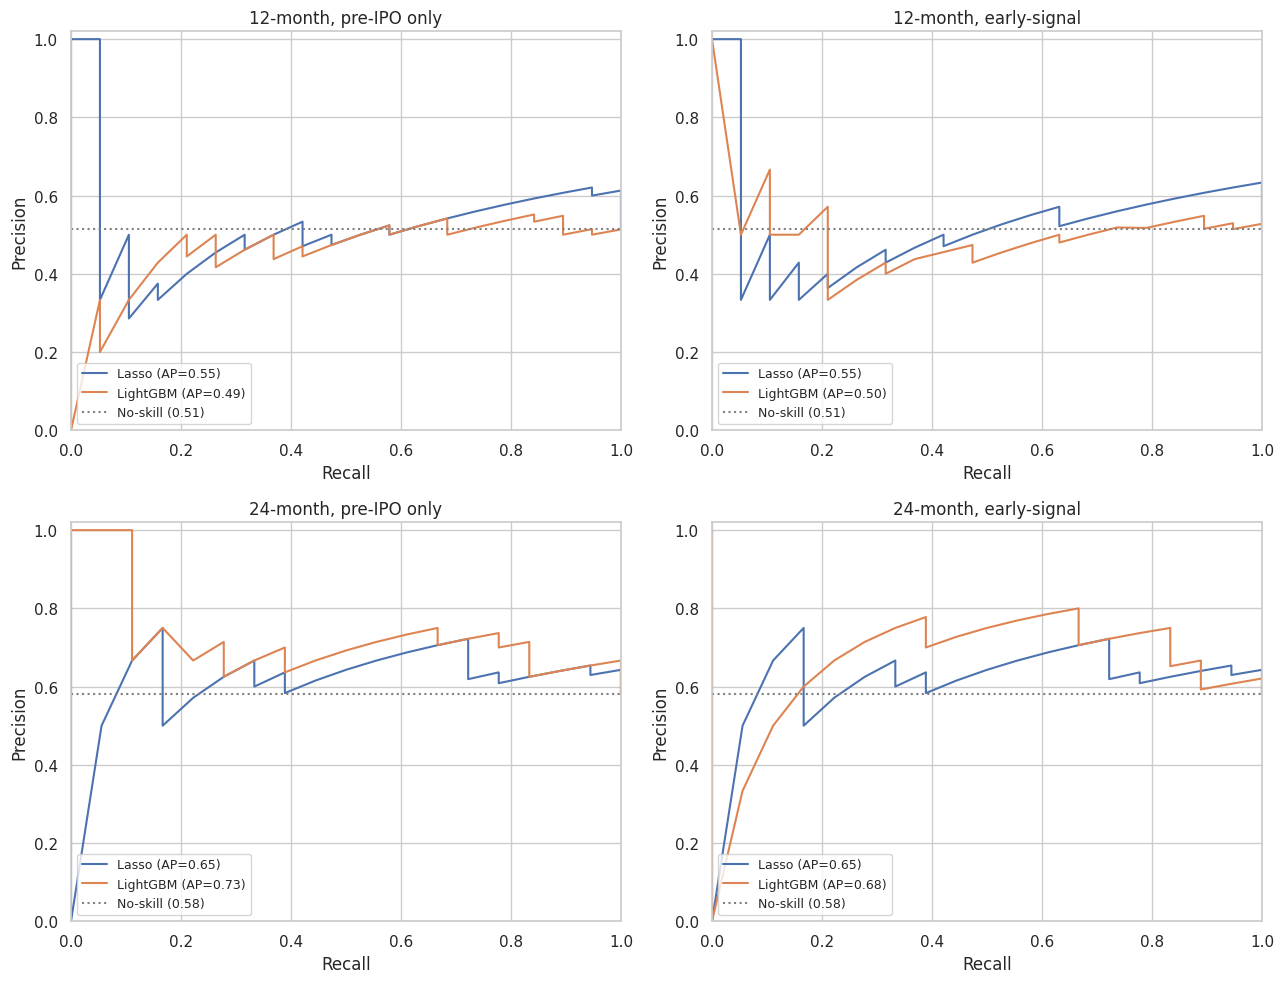

In [22]:
# 2x2 grid of PR curves
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
combo_keys = [("12m","pre_ipo"), ("12m","early_signal"),
              ("24m","pre_ipo"), ("24m","early_signal")]

for ax, key in zip(axes.flat, combo_keys):
    res = cls_results[key]
    y = res["y_test"]
    baseline = y.mean()
    for model_name in ["Lasso", "LightGBM"]:
        m = res["models"][model_name]
        prec, rec, _ = precision_recall_curve(y, m["proba_test"])
        ax.plot(rec, prec, label=f"{model_name} (AP={m['ap']:.2f})")
    ax.axhline(baseline, ls=":", color="gray", label=f"No-skill ({baseline:.2f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(res["label"])
    ax.set_xlim(0,1); ax.set_ylim(0,1.02)
    ax.legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.savefig("pr_curves.png", dpi=110, bbox_inches="tight")
plt.show()

## 10. Final model — retrain on train+val, evaluate once on test

Once we've chosen the model and its hyperparameters using the validation set,
we don't need the validation set anymore. So we combine train+val into one
bigger training set, refit the winning model on it (using the hyperparameters
chosen earlier), and predict on the test set exactly once. This single test
number is what we'd report as the model's performance on new data.

We pick the winning model based on the headline 12-month pre-IPO classifier.


In [23]:
# Pick the winning model on the headline 12m pre-IPO classifier
res = cls_results[("12m", "pre_ipo")]
winner = max(["Lasso", "LightGBM"], key=lambda m: res["models"][m]["ap"])
print(f"Winning model on 12m pre-IPO: {winner} (val/test AP={res['models'][winner]['ap']:.3f})")

# Re-prepare data: combine train + val
target_col = "target_12m_cls"
train, val, test = time_ordered_split(df, target_col)
trainval = pd.concat([train, val], axis=0).reset_index(drop=True)

uw_map, uw_global = fit_target_encoder_multi(trainval, UNDERWRITER_LIST_COL, target_col, smoothing=10)
trainval["uw_te"] = apply_target_encoder_multi(trainval, UNDERWRITER_LIST_COL, uw_map, uw_global)
test["uw_te"]     = apply_target_encoder_multi(test,     UNDERWRITER_LIST_COL, uw_map, uw_global)

num_features_full = NUM_FEATURES_PRE + ["uw_te"]
pre = make_preprocessor(num_features_full, "sector_grouped")
feat_cols = num_features_full + ["sector_grouped"]

X_tv = pre.fit_transform(trainval[feat_cols])
X_te = pre.transform(test[feat_cols])
y_tv = trainval[target_col].astype(int).values
y_te = test[target_col].astype(int).values

if winner == "Lasso":
    final = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 25), penalty="l1", solver="saga",
        cv=TimeSeriesSplit(n_splits=5), scoring="average_precision",
        max_iter=5000, random_state=RNG, class_weight="balanced",
    )
    final.fit(X_tv, y_tv)
    p_te = final.predict_proba(X_te)[:, 1]
else:
    bp = res["models"]["LightGBM"]["best_params"]
    final = LGBMClassifier(
        objective="binary",
        learning_rate=bp["learning_rate"], num_leaves=bp["num_leaves"], max_depth=bp["max_depth"],
        min_child_samples=5, reg_lambda=1.0,
        n_estimators=res["models"]["LightGBM"]["best_iter"],
        subsample=0.9, subsample_freq=5, colsample_bytree=0.9,
        random_state=RNG, verbose=-1,
    )
    final.fit(X_tv, y_tv)
    p_te = final.predict_proba(X_te)[:, 1]

ap_final = average_precision_score(y_te, p_te)
f1_final = f1_score(y_te, (p_te >= 0.5).astype(int))
cm = confusion_matrix(y_te, (p_te >= 0.5).astype(int))

print(f"\n=== FINAL MODEL ({winner}) — single test evaluation ===")
print(f"Test AP:  {ap_final:.3f}  (no-skill baseline = {y_te.mean():.3f})")
print(f"Test F1:  {f1_final:.3f}")
print(f"Confusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(cm, index=["true=0","true=1"], columns=["pred=0","pred=1"]))

Winning model on 12m pre-IPO: Lasso (val/test AP=0.548)

=== FINAL MODEL (Lasso) — single test evaluation ===
Test AP:  0.560  (no-skill baseline = 0.514)
Test F1:  0.513
Confusion matrix (rows=true, cols=pred):
        pred=0  pred=1
true=0       8      10
true=1       9      10


## 11. Notes

A few things to keep in mind when reading the results:

- The test set is the most recent IPOs. So
  the test performance is closer to "how well would this predict new IPOs"
  than a random in-sample estimate.

- Several features Lasso selected (underwriter, free-float-value, market cap,
  GYO sector) match the features that came back significant in the EDA
  hypothesis tests. That's a useful consistency check between the two stages
  of the project.

- Comparing the pre-IPO and early-signal variants tells us whether `tavan_days`
  carries signal beyond what's known at offering. EDA hypothesis 8 said it
  does at 24 months, so we expect to see it here too.

- We don't report accuracy because the classes aren't perfectly balanced
  (around 57/43 at 12m, 59/41 at 24m). AP and F1 are more meaningful here.

- 167 training rows is small, so we shouldn't over-interpret modest gains
  over the baseline. Some of the variance in test AP across runs is just
  noise from small samples.
